## **Coin Counter and Calculator Project - YOLOv8**

> ##### Import library
| name              | description       |
|-------------------|-------------------|
| **YOLO**              | model             |
| **PIL**               | display image in system viewer    |
| **IPython.display**   | display image in notebook    |

In [1]:
from ultralytics import YOLO
from PIL import Image as PILImage
from IPython.display import Image as IPyImage

import os
import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid


> ##### **for first train**
**Load a pretrained YOLOv8 small model**

In [2]:
model = YOLO("yolov8s.pt")

In [10]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

**Start Training**

| parameter              | description       |
|-------------------|-------------------|
| **data**              | path to dataset config             |
| **epochs**               | number of epoch    |
| **imgsz**   | img size that yolo resize before passing into model    |
| **plots**   | save results like graph|
| **workers**   | subprocess|
| **resume**   | in case the model didnt finish training all epochs|

In [ ]:
model.train(
    data="dataset/data.yaml", 
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=False,
    workers=0
)

> ##### **To train further**
**Load best model to train further**

In [ ]:
# Load checkpoint (best or last)
model = YOLO("runs/detect/train/weights/best.pt")

model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=False,
    workers=0
)

> ##### **Validation**

**Load best model to validate**

In [2]:
model = YOLO("runs/detect/train/weights/best.pt")

**Validate**

In [3]:
metrics = model.val(data="../dataset/data.yaml")

Ultralytics 8.3.202  Python-3.12.1 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 110.366.6 MB/s, size: 1341.8 KB)
val: Scanning C:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\dataset\valid\labels.cache... 234 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 234/234 233.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.0it/s 7.6s0.3s
                   all        234        494       0.99      0.993      0.994      0.958
                     1         87        161      0.994      0.981      0.994      0.955
                    10         80        138      0.997          1      0.995      0.956
                     2         49         60      0.982          1      0.995      0.955
                     5         82      

> ##### **Test Prediction**

In [7]:
preds = model("../test_images/test_9.jpg")
preds[0].show()


image 1/1 c:\Users\Jin\Documents\Work\2025-1\Digital-Image-Processing\Coin-Counter-Project\YOLOv8\..\test_images\test_9.jpg: 480x640 1 1, 119.8ms
Speed: 6.5ms preprocess, 119.8ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


>##### **Performance Analysis**

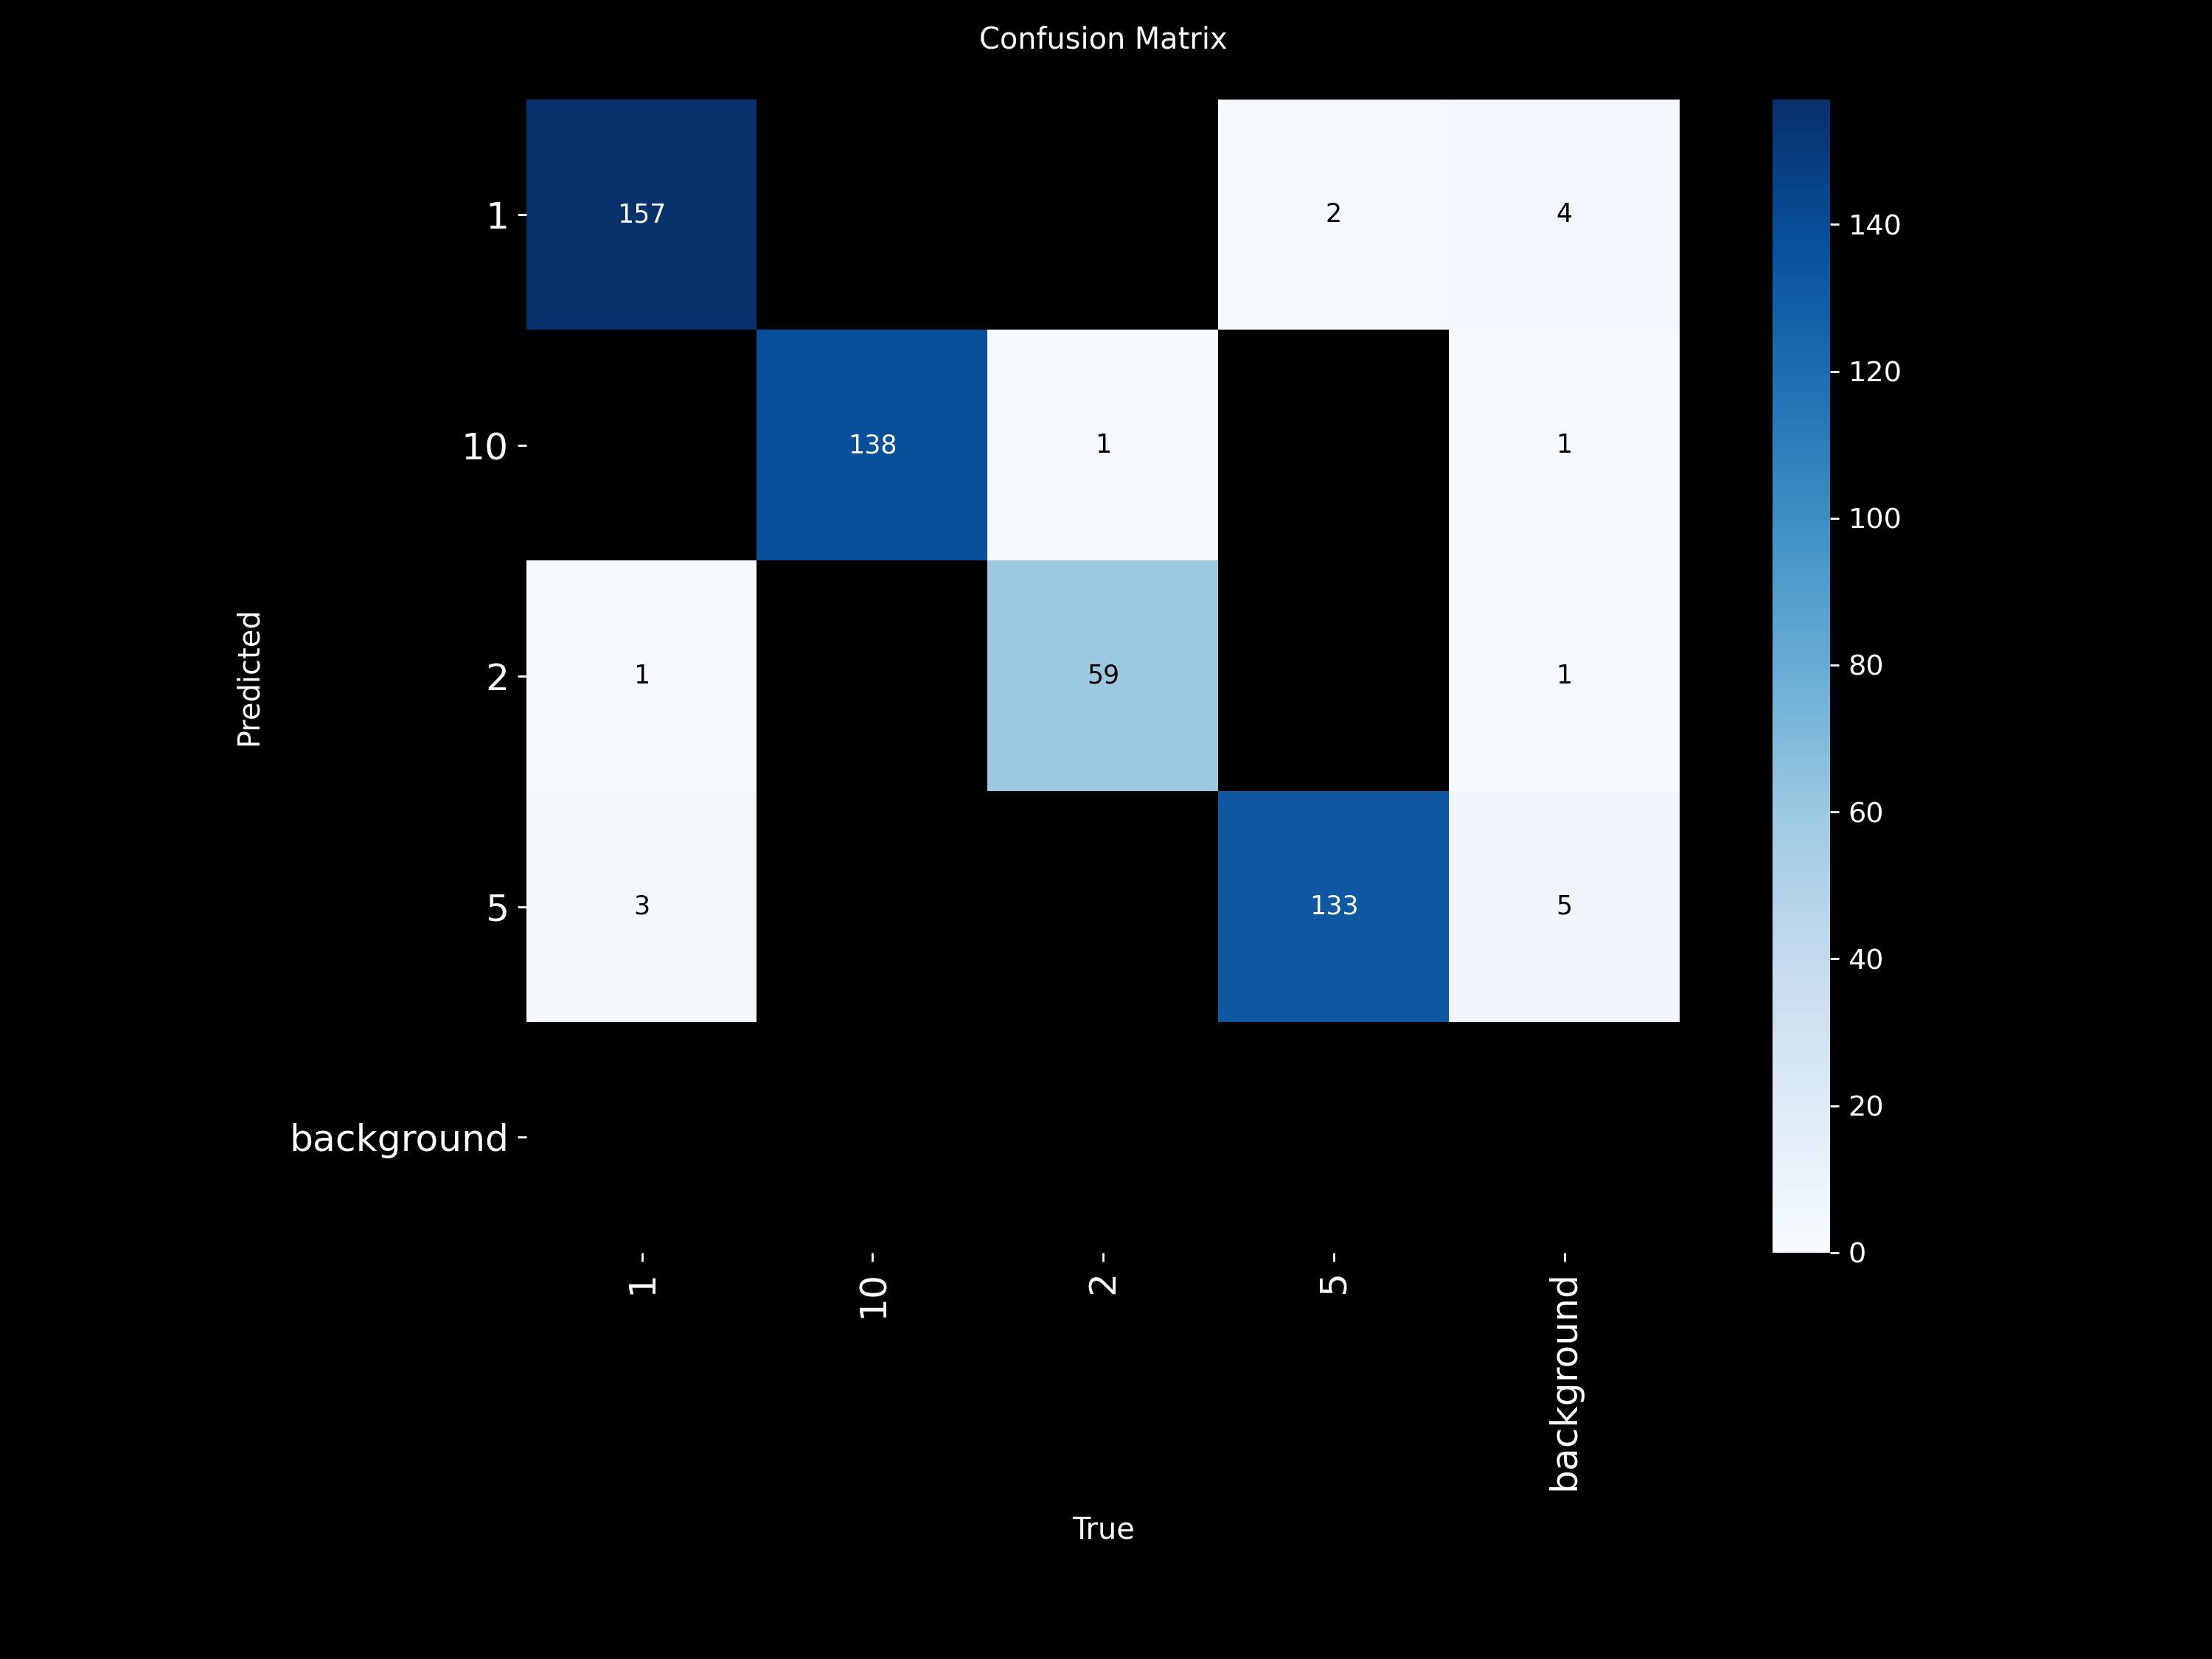

In [ ]:
display(IPyImage(filename='runs/detect/train/confusion_matrix.png', width=800))

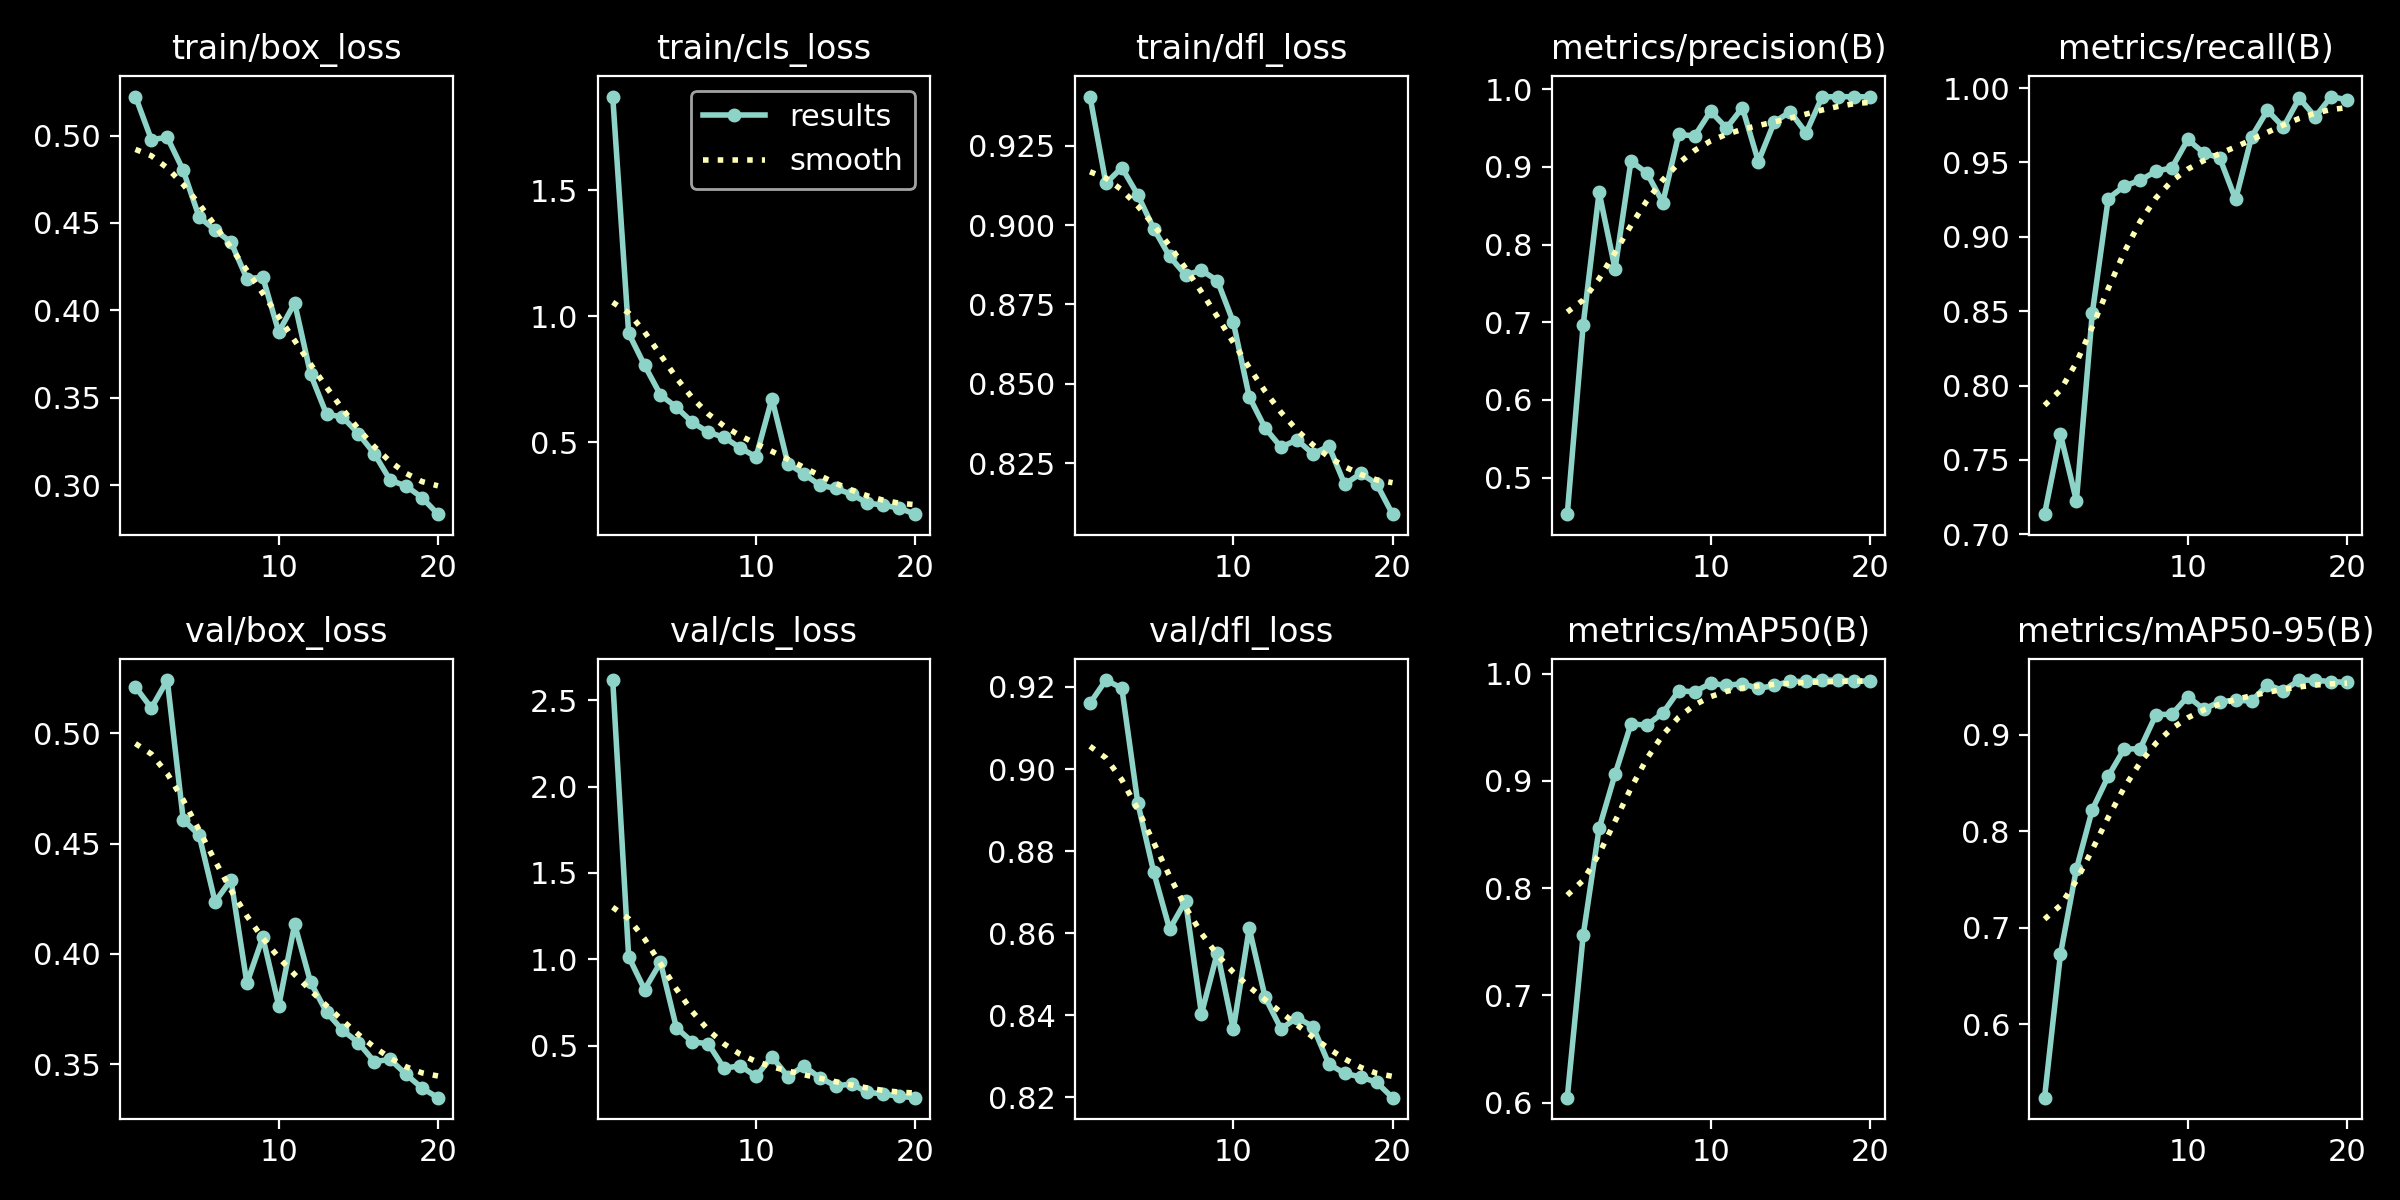

In [ ]:
display(IPyImage(filename=f'runs/detect/train/results.png', width=1000))
# img = PILImage.open("runs/detect/train/results.png")
# img.show()

In [ ]:
display(IPyImage(filename=f'runs/detect/train/val_batch0_pred.jpg', width=800))

img = PILImage.open("runs/detect/train/val_batch0_pred.jpg")
img.show()

> ##### **In case model didn't finish training (error etc.)**
**Load last model to continue training**

In [ ]:
# Load checkpoint (last)
model = YOLO("runs/detect/train/weights/last.pt")

model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    plots=True,
    resume=True,
    workers=0
)